[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_02_classification.ipynb)

In [1]:
# Imports for math, plotting, and logistic classification.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, log_loss)
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

  PART A — Why MSE is wrong for classification


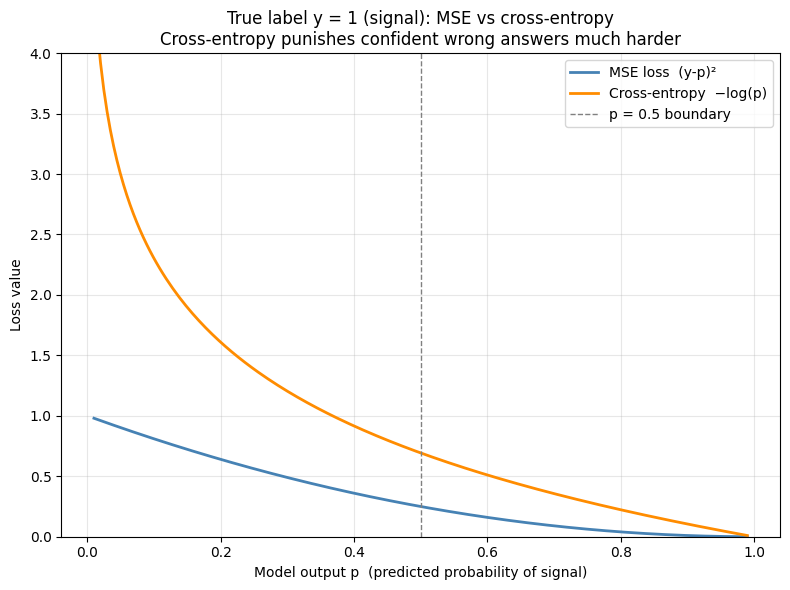


MSE when p=0.01 (very wrong): 0.980
Cross-entropy when p=0.01   : 4.605   ← much larger penalty!

Cross-entropy forces the model to be calibrated (honest about confidence).
MSE treats "p=0.01 when truth=1" almost the same as "p=0.4 when truth=1".
Cross-entropy screams at overconfident mistakes — which is what we want.



In [2]:
# =============================================================================
# PART A — Why MSE is usually not the best for classification
# =============================================================================
print("=" * 60)
print("  PART A — Why MSE is wrong for classification")
print("=" * 60)

# Example setup:
# - true label is y=1 (this event is really a signal)
# - model outputs probability p (how confident it is)

y_true_example = 1.0   # true label

probs   = np.linspace(0.01, 0.99, 200)   # range of possible model outputs

mse_loss = (y_true_example - probs) ** 2

# Cross-entropy loss:  L = - [ y*log(p) + (1-y)*log(1-p) ]
# For y=1 this simplifies to:  L = -log(p)
# → if p→1 (confident and correct)   : L→0   (no penalty)
# → if p→0 (confident and WRONG)     : L→∞   (catastrophic penalty)
cross_entropy_loss = -np.log(probs)      # simplified for y=1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(probs, mse_loss,           color="steelblue",  lw=2, label="MSE loss  (y-p)²")
ax.plot(probs, cross_entropy_loss, color="darkorange", lw=2, label="Cross-entropy  −log(p)")
ax.axvline(0.5, color="gray", lw=1, linestyle="--", label="p = 0.5 boundary")
ax.set_xlabel("Model output p  (predicted probability of signal)")
ax.set_ylabel("Loss value")
ax.set_title("True label y = 1 (signal): MSE vs cross-entropy\n"
             "Cross-entropy punishes confident wrong answers much harder")
ax.legend()
ax.set_ylim(0, 4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./step2_loss_comparison.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("""
MSE when p=0.01 (very wrong): {:.3f}
Cross-entropy when p=0.01   : {:.3f}   ← much larger penalty!

Cross-entropy forces the model to be calibrated (honest about confidence).
MSE treats "p=0.01 when truth=1" almost the same as "p=0.4 when truth=1".
Cross-entropy screams at overconfident mistakes — which is what we want.
""".format((1 - 0.01)**2, -np.log(0.01)))

  PART B — The Sigmoid function

The linear model gives us:  z = θ₀ + θ₁·x₁ + θ₂·x₂ + ...
z can be ANY real number: -∞ to +∞.

We need a probability p ∈ [0,1].

Solution: wrap z in the sigmoid:
    σ(z) = 1 / (1 + exp(-z))

    z → -∞  ⟹  σ → 0   (definitely noise)
    z =  0  ⟹  σ = 0.5  (uncertain — decision boundary)
    z → +∞  ⟹  σ → 1   (definitely signal)

This is LOGISTIC REGRESSION.



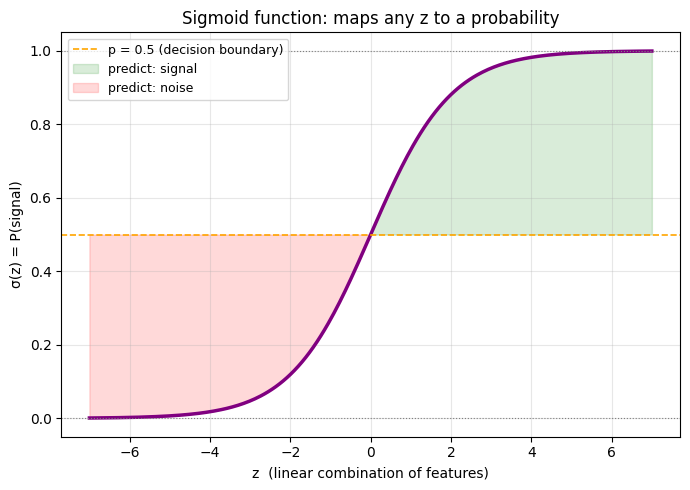

In [3]:
# =============================================================================
# PART B — The Sigmoid function: squashing ℝ → [0, 1]
# =============================================================================
print("=" * 60)
print("  PART B — The Sigmoid function")
print("=" * 60)

print("""
The linear model gives us:  z = θ₀ + θ₁·x₁ + θ₂·x₂ + ...
z can be ANY real number: -∞ to +∞.

We need a probability p ∈ [0,1].

Solution: wrap z in the sigmoid:
    σ(z) = 1 / (1 + exp(-z))

    z → -∞  ⟹  σ → 0   (definitely noise)
    z =  0  ⟹  σ = 0.5  (uncertain — decision boundary)
    z → +∞  ⟹  σ → 1   (definitely signal)

This is LOGISTIC REGRESSION.
""")

z = np.linspace(-7, 7, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(z, sigmoid, color="purple", lw=2.5)
ax.axhline(0.5, color="orange", lw=1.2, linestyle="--", label="p = 0.5 (decision boundary)")
ax.axhline(0.0, color="gray",   lw=0.8, linestyle=":")
ax.axhline(1.0, color="gray",   lw=0.8, linestyle=":")
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5),
                alpha=0.15, color="green", label="predict: signal")
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5),
                alpha=0.15, color="red",   label="predict: noise")
ax.set_xlabel("z  (linear combination of features)")
ax.set_ylabel("σ(z) = P(signal)")
ax.set_title("Sigmoid function: maps any z to a probability")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./step2_sigmoid.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [4]:
# =============================================================================
# PART C — Fake GW trigger data
# =============================================================================
print("=" * 60)
print("  PART C — Fake GW trigger dataset")
print("=" * 60)

N_noise  = 400   # noise triggers (glitches)
N_signal = 200   # real GW events (rarer — class imbalance is realistic!)

# NOISE triggers:
#   - SNR: moderate, wide scatter (glitches can have high SNR too!)
#   - Chirp mass: all over the place (no physical chirp)
snr_noise   = rng.normal(loc=7.0,  scale=2.5, size=N_noise).clip(4, 20)
mass_noise  = rng.uniform(5, 80,               size=N_noise)

# SIGNAL triggers (binary black-hole or neutron-star mergers):
#   - SNR: generally higher
#   - Chirp mass: physically plausible range, tighter
snr_signal  = rng.normal(loc=11.0, scale=2.0, size=N_signal).clip(4, 25)
mass_signal = rng.normal(loc=25.0, scale=8.0,  size=N_signal).clip(1, 80)

# Stack into arrays
X_snr   = np.concatenate([snr_noise,  snr_signal])
X_mass  = np.concatenate([mass_noise, mass_signal])
y       = np.concatenate([np.zeros(N_noise), np.ones(N_signal)])

X = np.column_stack([X_snr, X_mass])   # shape: (N, 2) — 2 features per event

print(f"Total triggers : {len(y)}")
print(f"  Noise (0)    : {np.sum(y == 0)}")
print(f"  Signal (1)   : {np.sum(y == 1)}")
print(f"\nFeatures per trigger:")
print(f"  x₁ = SNR          range [{X_snr.min():.1f},  {X_snr.max():.1f}]")
print(f"  x₂ = chirp mass   range [{X_mass.min():.1f}, {X_mass.max():.1f}] M☉\n")

  PART C — Fake GW trigger dataset
Total triggers : 600
  Noise (0)    : 400
  Signal (1)   : 200

Features per trigger:
  x₁ = SNR          range [4.0,  17.4]
  x₂ = chirp mass   range [5.1, 79.9] M☉



### Using a prebuilt sklearn classifier

In this section, we use an already implemented classifier from `scikit-learn` instead of writing every optimization detail from scratch. This gives us a reliable, well-tested baseline so we can focus on understanding classification behavior, predictions, and evaluation.

For more details on how sklearn classifiers work and available options, see the official documentation:

- https://scikit-learn.org/stable/supervised_learning.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [5]:
# =============================================================================
# PART D — Train a Logistic Regression classifier
# =============================================================================
print("=" * 60)
print("  PART D — Training (minimising cross-entropy)")
print("=" * 60)

# Split into training and test sets (never evaluate on training data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features to mean=0 and std=1.
# This helps optimization behave better because both features are on similar ranges.
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # learn mean/std on training set only
X_test_s  = scaler.transform(X_test)        # apply same scaling to test set

# Train logistic regression (it learns parameters by minimizing cross-entropy loss).
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)

print(f"Learned weights (θ):")
print(f"  θ_SNR        = {clf.coef_[0][0]:.4f}  (positive → higher SNR = more signal-like)")
print(f"  θ_chirp_mass = {clf.coef_[0][1]:.4f}  (positive → higher mass = more signal-like)")
print(f"  θ_bias       = {clf.intercept_[0]:.4f}\n")

  PART D — Training (minimising cross-entropy)
Learned weights (θ):
  θ_SNR        = 2.0430  (positive → higher SNR = more signal-like)
  θ_chirp_mass = -0.8953  (positive → higher mass = more signal-like)
  θ_bias       = -1.3879



In [6]:
# =============================================================================
# PART E — Evaluate on test set
# =============================================================================
print("=" * 60)
print("  PART E — Evaluation on held-out test set")
print("=" * 60)

y_pred       = clf.predict(X_test_s)
y_pred_proba = clf.predict_proba(X_test_s)[:, 1]   # P(signal) for each trigger

print(classification_report(y_test, y_pred,
                             target_names=["Noise (0)", "Signal (1)"]))

# Cross-entropy on the test set
test_loss = log_loss(y_test, y_pred_proba)
print(f"Test cross-entropy loss: {test_loss:.4f}  (lower = better)\n")

print("""
Reading the classification report:
  Precision : of all events I called "signal", how many truly were?
              → False alarm rate matters a lot in GW astronomy!
  Recall    : of all true signals, how many did I find?
              → Missing a merger is also bad.
  F1 score  : harmonic mean of precision and recall.

In GW searches:
  Precision ↔ False Alarm Rate (FAR)
  Recall    ↔ Detection Efficiency
  ROC curve  ↔ the full precision/recall trade-off at every threshold
""")

  PART E — Evaluation on held-out test set
              precision    recall  f1-score   support

   Noise (0)       0.85      0.90      0.87       100
  Signal (1)       0.77      0.68      0.72        50

    accuracy                           0.83       150
   macro avg       0.81      0.79      0.80       150
weighted avg       0.82      0.83      0.82       150

Test cross-entropy loss: 0.3441  (lower = better)


Reading the classification report:
  Precision : of all events I called "signal", how many truly were?
              → False alarm rate matters a lot in GW astronomy!
  Recall    : of all true signals, how many did I find?
              → Missing a merger is also bad.
  F1 score  : harmonic mean of precision and recall.

In GW searches:
  Precision ↔ False Alarm Rate (FAR)
  Recall    ↔ Detection Efficiency
  ROC curve  ↔ the full precision/recall trade-off at every threshold



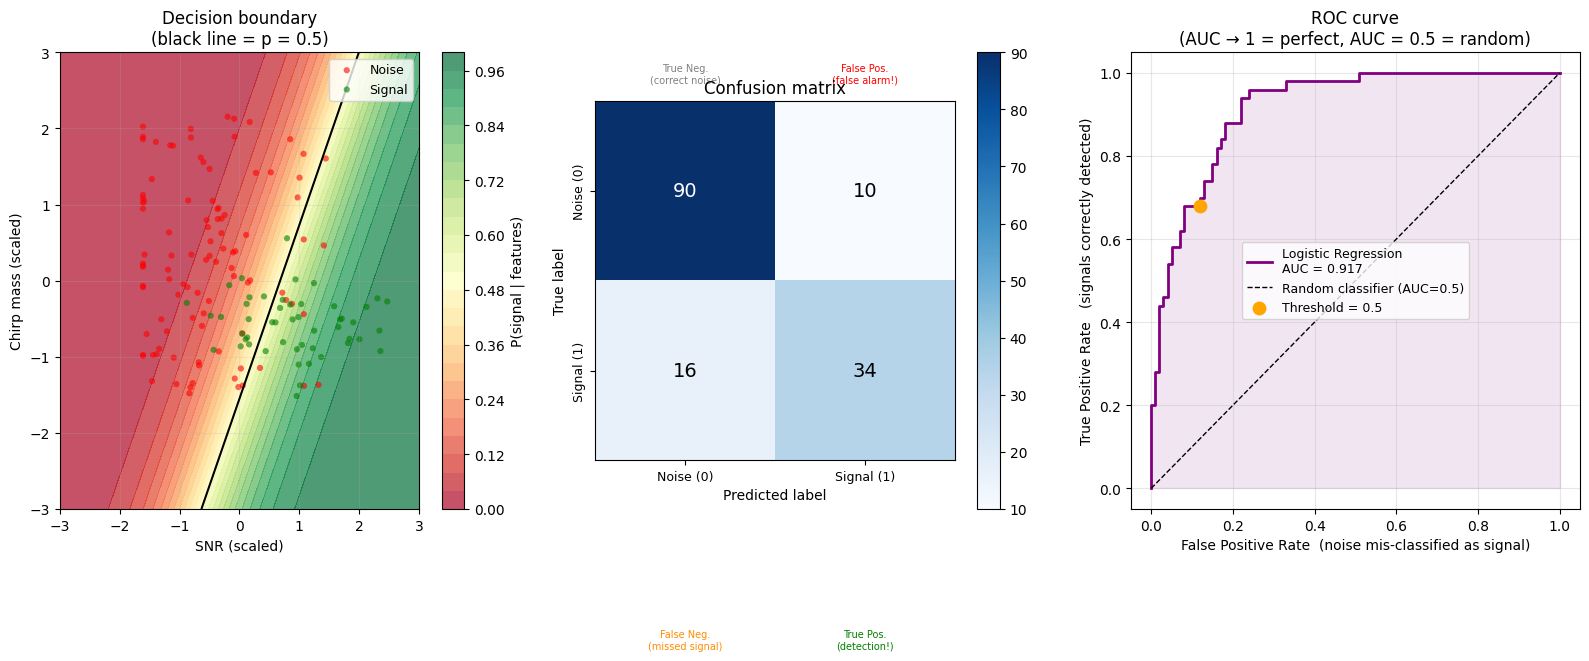

Plots saved.


In [7]:
# =============================================================================
# PART F — Visualise everything
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#fig.suptitle("Step 2 — Classification: GW signal vs. noise triggers", fontsize=13)

# ── 1. Decision boundary in feature space ─────────────────────────────────
ax = axes[0]
# Create a grid over the scaled feature space
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

cf = ax.contourf(xx, yy, Z, levels=30, cmap="RdYlGn", alpha=0.7, vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label="P(signal | features)")
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)

# Plot test points
mask0 = (y_test == 0)
mask1 = (y_test == 1)
ax.scatter(X_test_s[mask0, 0], X_test_s[mask0, 1],
           c="red",   s=20, alpha=0.6, label="Noise",  edgecolors="none")
ax.scatter(X_test_s[mask1, 0], X_test_s[mask1, 1],
           c="green", s=20, alpha=0.6, label="Signal", edgecolors="none")

ax.set_xlabel("SNR (scaled)")
ax.set_ylabel("Chirp mass (scaled)")
ax.set_title("Decision boundary\n(black line = p = 0.5)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# ── 2. Confusion matrix ───────────────────────────────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
im = ax2.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax2)
labels = ["Noise (0)", "Signal (1)"]
ax2.set_xticks([0, 1]); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(labels, fontsize=9, rotation=90, va="center")
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")
ax2.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]),
                 ha="center", va="center", fontsize=14,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
# Annotate quadrants
ax2.text(0, -0.6, "True Neg.\n(correct noise)", ha="center", fontsize=7, color="gray")
ax2.text(1, -0.6, "False Pos.\n(false alarm!)",  ha="center", fontsize=7, color="red")
ax2.text(0, 2.55, "False Neg.\n(missed signal)", ha="center", fontsize=7, color="darkorange")
ax2.text(1, 2.55, "True Pos.\n(detection!)",     ha="center", fontsize=7, color="green")

# ── 3. ROC curve (key plot in physics searches) ────────────────────────────
ax3 = axes[2]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color="purple", lw=2,
         label=f"Logistic Regression\nAUC = {roc_auc:.3f}")
ax3.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC=0.5)")
ax3.fill_between(fpr, tpr, alpha=0.1, color="purple")

# Mark the p=0.5 operating point
idx_half = np.argmin(np.abs(thresholds - 0.5))
ax3.scatter(fpr[idx_half], tpr[idx_half],
            color="orange", s=80, zorder=5, label="Threshold = 0.5")

ax3.set_xlabel("False Positive Rate  (noise mis-classified as signal)")
ax3.set_ylabel("True Positive Rate   (signals correctly detected)")
ax3.set_title("ROC curve\n(AUC → 1 = perfect, AUC = 0.5 = random)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./step2_classification.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Plots saved.")

In [8]:
# =============================================================================
# PART G — Key takeaways
# =============================================================================
print("\n" + "=" * 60)
print("  KEY TAKEAWAYS — STEP 2")
print("=" * 60)
print("""
1. CLASSIFICATION outputs a PROBABILITY p = P(signal | x).
   The model architecture is: z = θᵀx,  then  p = σ(z).

2. The LOSS FUNCTION is cross-entropy:
      L(θ) = -(1/N) Σ [ yᵢ log(pᵢ) + (1-yᵢ) log(1-pᵢ) ]
   We still minimise L(θ) — same goal as Step 1!

3. The DECISION BOUNDARY is where p = 0.5,  i.e.  σ(z) = 0.5
   → z = 0 → θᵀx = 0.
   For 2 features, it's a line; for N features, a hyperplane.

4. EVALUATION in physics searches:
   - ROC curve:  detection efficiency vs. false alarm rate at every threshold.
   - AUC:        area under ROC; 1 = perfect, 0.5 = random.
   - The orange dot on the ROC is where we operate at p > 0.5.
   - In real GW searches (PyCBC, GstLAL) these are called
     "sensitivity" and "FAR" — same concept.

5. Class IMBALANCE is realistic:
   We have 400 noise + 200 signal triggers.
   Real GW datasets have millions of noise glitches per real event.
   We'll handle this properly in later steps.

UP NEXT — STEP 3:
   Neural Networks:
   "What if the decision boundary isn't a straight line?"
   → Stack multiple layers of σ(z) → universal function approximator.
   → Loss is still cross-entropy (or MSE), still minimised by gradient descent.
""")


  KEY TAKEAWAYS — STEP 2

1. CLASSIFICATION outputs a PROBABILITY p = P(signal | x).
   The model architecture is: z = θᵀx,  then  p = σ(z).

2. The LOSS FUNCTION is cross-entropy:
      L(θ) = -(1/N) Σ [ yᵢ log(pᵢ) + (1-yᵢ) log(1-pᵢ) ]
   We still minimise L(θ) — same goal as Step 1!

3. The DECISION BOUNDARY is where p = 0.5,  i.e.  σ(z) = 0.5
   → z = 0 → θᵀx = 0.
   For 2 features, it's a line; for N features, a hyperplane.

4. EVALUATION in physics searches:
   - ROC curve:  detection efficiency vs. false alarm rate at every threshold.
   - AUC:        area under ROC; 1 = perfect, 0.5 = random.
   - The orange dot on the ROC is where we operate at p > 0.5.
   - In real GW searches (PyCBC, GstLAL) these are called
     "sensitivity" and "FAR" — same concept.

5. Class IMBALANCE is realistic:
   We have 400 noise + 200 signal triggers.
   Real GW datasets have millions of noise glitches per real event.
   We'll handle this properly in later steps.

UP NEXT — STEP 3:
   Neural Netwo